# Cómo una membrana flexible saca agua del aire 5 veces más rápido

**425 millones de personas no tienen acceso a agua limpia.** Y el aire que respiras —incluso en el desierto— está lleno de humedad. El problema nunca fue dónde está el agua. Es **qué tan rápido se puede atrapar y soltar**.

Un equipo en China construyó una membrana flexible de zeolitas que llega al 50% de su capacidad en **4.6 minutos**. La competencia tarda entre 11 y 48 minutos. Y al final del día, una hoja de este material colecta más agua de la que pesa.

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-14-zeolitas-agua-aire/notebook.ipynb)

**Paper:** Bai et al. (2026) · *Nature Water* · [DOI: 10.1038/s44221-026-00649-2](https://doi.org/10.1038/s44221-026-00649-2)  \
**Video corto:** [Pendiente]


## El problema de extraer agua del aire

La técnica se llama **SAWH** (*Sorption-based Atmospheric Water Harvesting* — captura por sorción del agua atmosférica). La idea es simple: un material poroso atrapa moléculas de agua del aire, después se calienta para liberarlas, y se repite.

El cuello de botella nunca fue capturar. Los polvos sorbentes tradicionales atrapan bien, pero al apilarlos en un dispositivo real **la cinética se desploma**: el agua tiene que viajar entre los granos, y eso es lento. La pregunta del paper es: ¿qué pasa si en vez de polvo apilado fabricamos una **membrana** estructurada, con poros jerárquicos que dejen pasar las moléculas sin trabarse?

El material se llama EMM-8@TPU: nanoláminas de zeolita EMM-8 dentro de una matriz de poliuretano termoplástico. Veamos qué tan rápido absorbe, qué tan rápido suelta, y cuánta agua puede sacar en un día completo.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
RH_BAJA = 38.1           # % humedad relativa baja (condición seca)
RH_MEDIA = 59.3          # % humedad relativa media (condición óptima reportada)
T_DESORCION_OBJETIVO = 80  # °C objetivo de desorción rápida
PRODUCTIVIDAD_TOP_LITERATURA = 8.96  # g/g/d mejor competidor (CAL @ 72.5% RH)
FUENTE = 'Fuente: Bai et al. (2026), Nature Water | Datos: Source Data Fig. 3 & 5 (MOESM)'

COLOR_PRINCIPAL = '#2563EB'   # azul CaM — EMM-8@TPU
COLOR_ALERTA = '#DC2626'      # rojo — competidor / referencia
COLOR_SECUNDARIO = '#059669'  # emerald — datos auxiliares
COLOR_REFERENCIA = '#D97706'  # amber — línea de referencia
COLOR_CONTEXTO = '#BBBBBB'    # gris — contexto

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Cargar estilo CaM (local → fallback GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de los 5 datasets
sorcion = pd.read_csv('datos/sorcion_kinetica.csv')
desorcion = pd.read_csv('datos/desorcion_kinetica.csv')
comparada = pd.read_csv('datos/cinetica_sorcion_comparada.csv')
productividad = pd.read_csv('datos/productividad_sorbentes.csv')
ciclado = pd.read_csv('datos/ciclado_productividad.csv')

print(f"Sorción cinética:        {len(sorcion):3d} filas | RH={sorted(sorcion['rh_pct'].unique())}")
print(f"Desorción cinética:      {len(desorcion):3d} filas | T(°C)={sorted(desorcion['T_C'].unique())}")
print(f"Comparativa cinética:    {len(comparada):3d} filas | sorbentes={comparada['sorbente'].nunique()}")
print(f"Productividad sorbentes: {len(productividad):3d} filas | sorbentes={productividad['sorbente'].nunique()}")
print(f"Ciclado 24h:             {len(ciclado):3d} filas | ciclos={ciclado['ciclo'].max()}")


Sorción cinética:         54 filas | RH=[np.int64(30), np.int64(50), np.int64(70)]
Desorción cinética:       45 filas | T(°C)=[np.int64(65), np.int64(70), np.int64(80)]
Comparativa cinética:    148 filas | sorbentes=7
Productividad sorbentes:  19 filas | sorbentes=15
Ciclado 24h:              72 filas | ciclos=72


## Cuánta agua sacan los mejores sorbentes del mundo

Aquí están los sorbentes más competitivos publicados, cruzados con la membrana del paper.


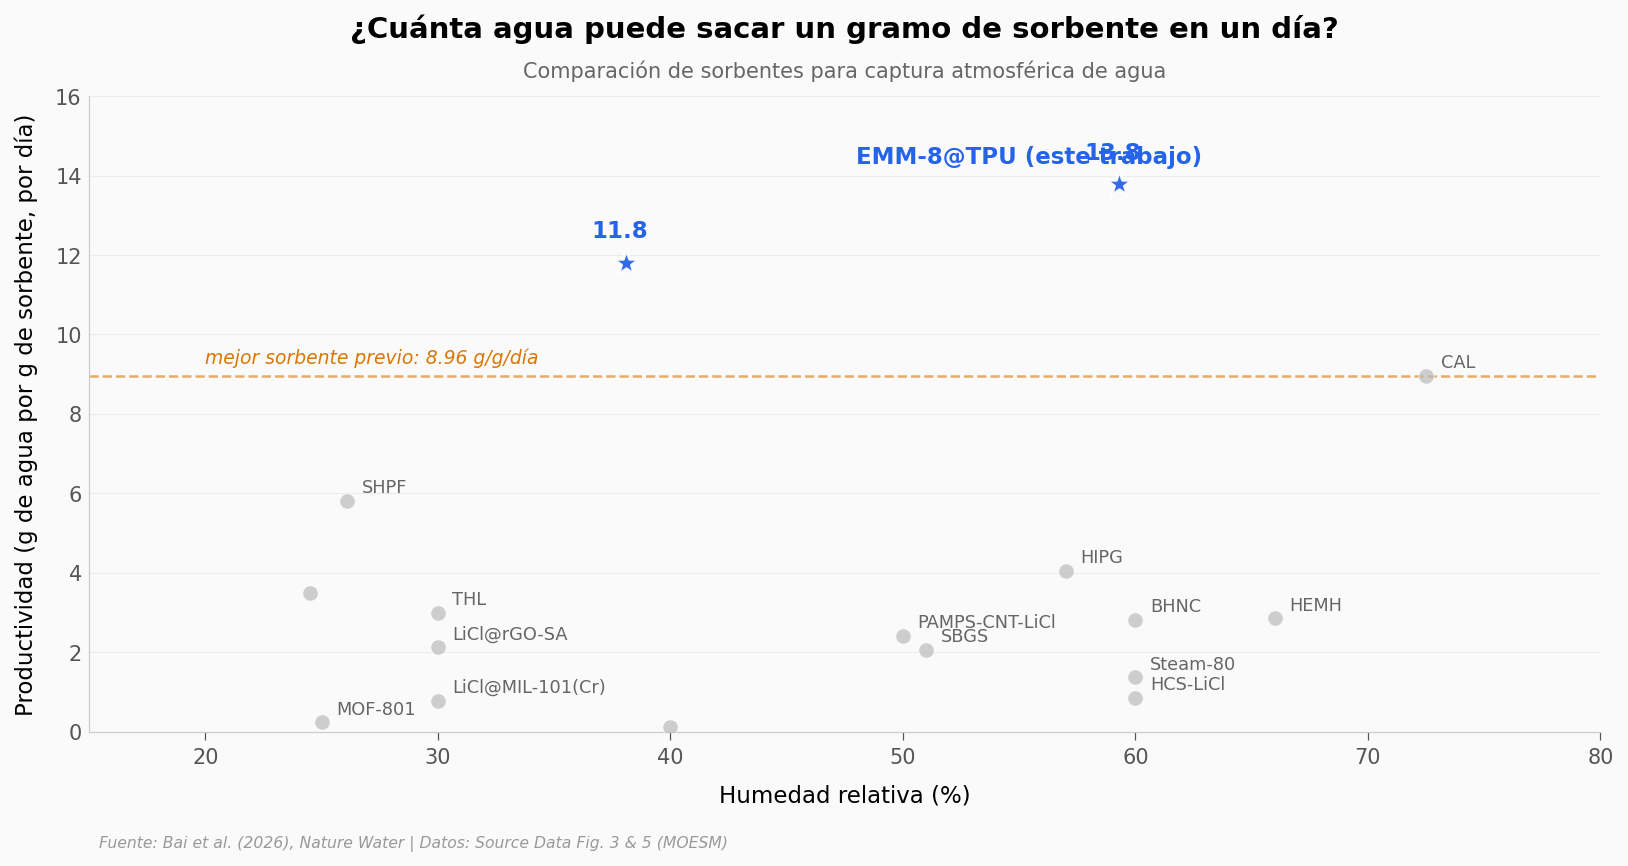

In [2]:
# Gráfica hero: productividad por sorbente vs humedad relativa
fig, ax = plt.subplots(figsize=(13, 5.5))

# Separar EMM-8@TPU del resto
emm = productividad[productividad['sorbente'].str.contains('EMM-8@TPU')]
resto = productividad[~productividad['sorbente'].str.contains('EMM-8@TPU')]

# Resto de sorbentes — gris contexto
for nombre, grp in resto.groupby('sorbente'):
    ax.scatter(grp['rh_pct'], grp['productividad_g_g_d'],
               color=COLOR_CONTEXTO, s=55, alpha=0.7,
               edgecolors='white', linewidths=0.5, zorder=4)
    # Etiqueta inline al lado del punto
    x, y = grp['rh_pct'].iloc[0], grp['productividad_g_g_d'].iloc[0]
    ax.annotate(nombre.split(' (')[0], xy=(x, y), xytext=(7, 4),
                textcoords='offset points', fontsize=8.5, color='#666666')

# EMM-8@TPU destacado
ax.scatter(emm['rh_pct'], emm['productividad_g_g_d'],
           color=COLOR_PRINCIPAL, s=180, alpha=0.95,
           edgecolors='white', linewidths=1.5, zorder=6, marker='*')
for _, row in emm.iterrows():
    ax.annotate(f"{row['productividad_g_g_d']:.1f}",
                xy=(row['rh_pct'], row['productividad_g_g_d']),
                xytext=(-3, 12), textcoords='offset points',
                fontsize=11, fontweight='bold', color=COLOR_PRINCIPAL, ha='center')

# Línea de referencia: mejor competidor anterior
ax.axhline(y=PRODUCTIVIDAD_TOP_LITERATURA, color=COLOR_REFERENCIA,
           linewidth=1.2, linestyle='--', alpha=0.6, zorder=2)
ax.text(20, PRODUCTIVIDAD_TOP_LITERATURA + 0.3,
        f'mejor sorbente previo: {PRODUCTIVIDAD_TOP_LITERATURA} g/g/día',
        fontsize=9, color=COLOR_REFERENCIA, style='italic')

# Etiqueta inline para EMM-8@TPU
ax.text(48, 14.3, 'EMM-8@TPU (este trabajo)',
        fontsize=11, fontweight='bold', color=COLOR_PRINCIPAL)

ax.set_xlabel('Humedad relativa (%)', fontsize=11)
ax.set_ylabel('Productividad (g de agua por g de sorbente, por día)', fontsize=11)
ax.set_title('¿Cuánta agua puede sacar un gramo de sorbente en un día?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Comparación de sorbentes para captura atmosférica de agua',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(15, 80)
ax.set_ylim(0, 16)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_productividad_sorbentes.png', dpi=200, bbox_inches='tight')
plt.show()


La estrella azul vive sola arriba a la derecha. A 38% de humedad —condiciones secas, casi de desierto interior— ya supera a todos los sorbentes anteriores medidos a humedades mucho más altas. A 59% sube a **13.79 g/g/día**, un 54% por encima del mejor reportado hasta ahora (CAL, que necesita un 72.5% de humedad para llegar a 8.96).

El detalle importante: la ventaja no es solo cuánta agua sale, sino **a qué humedad sale**. Para muchas regiones áridas, 38% es la condición real. Llegar a 11.81 g/g/día en ese rango cambia la cuenta de viabilidad del dispositivo.


## La cinética: cuánto tarda en llenarse

La productividad alta solo importa si la membrana **se llena rápido**. Si tarda horas, no caben ciclos suficientes en un día. Veamos cuántos minutos necesita para empezar a soltar agua aprovechable.


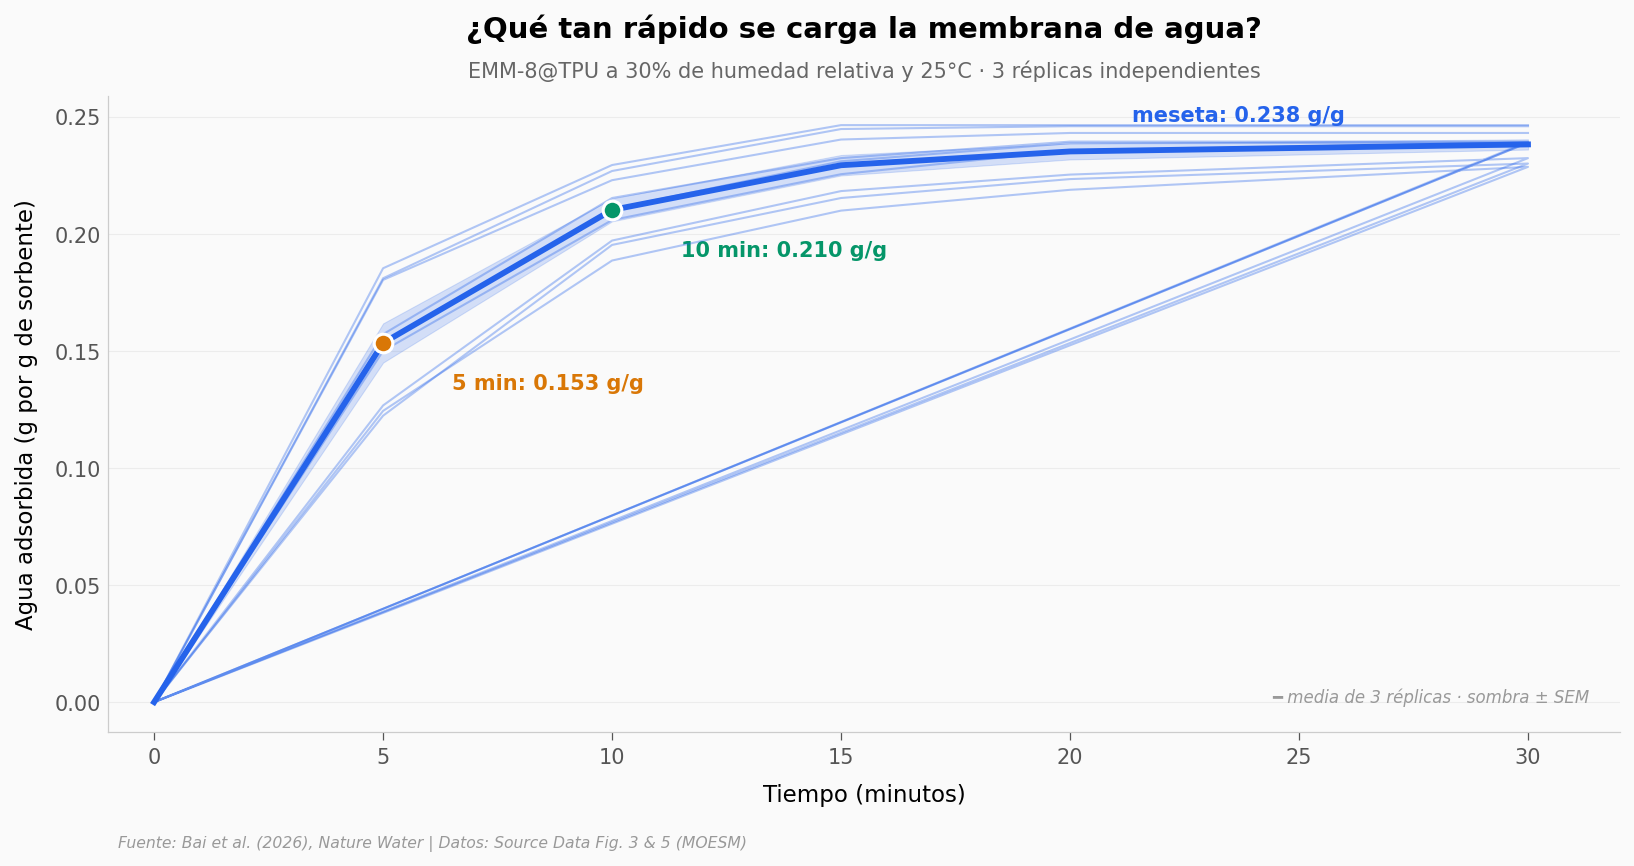

In [3]:
# Cinética de sorción @ 30% RH — 3 réplicas independientes
fig, ax = plt.subplots(figsize=(13, 5.5))

# 3 réplicas finas + curva media gruesa
medias = sorcion.groupby('tiempo_min')['water_uptake_g_g'].agg(['mean', 'std', 'count']).reset_index()
medias['sem'] = medias['std'] / np.sqrt(medias['count'])

for sample in sorted(sorcion['sample'].unique()):
    sub = sorcion[sorcion['sample'] == sample]
    ax.plot(sub['tiempo_min'], sub['water_uptake_g_g'],
            color=COLOR_PRINCIPAL, linewidth=1, alpha=0.35, zorder=4)

ax.plot(medias['tiempo_min'], medias['mean'],
        color=COLOR_PRINCIPAL, linewidth=2.8, zorder=6)
ax.fill_between(medias['tiempo_min'],
                medias['mean'] - medias['sem'],
                medias['mean'] + medias['sem'],
                color=COLOR_PRINCIPAL, alpha=0.18, zorder=3)

# Marcadores clave: 5 min, 10 min, 30 min
for t_min, color, label_off in [(5, COLOR_REFERENCIA, 18), (10, COLOR_SECUNDARIO, 14)]:
    val = medias[medias['tiempo_min'] == t_min]['mean'].values
    if len(val):
        v = val[0]
        ax.scatter(t_min, v, color=color, s=80, zorder=7,
                   edgecolors='white', linewidths=1.5)
        ax.annotate(f'{t_min} min: {v:.3f} g/g',
                    xy=(t_min, v), xytext=(t_min + 1.5, v - 0.02),
                    fontsize=10, color=color, fontweight='bold')

# Máximo
v_max = medias['mean'].max()
t_max = medias[medias['mean'] == v_max]['tiempo_min'].values[0]
ax.text(t_max - 4, v_max + 0.01, f'meseta: {v_max:.3f} g/g',
        fontsize=10, color=COLOR_PRINCIPAL, fontweight='bold', ha='right')

ax.set_xlabel('Tiempo (minutos)', fontsize=11)
ax.set_ylabel('Agua adsorbida (g por g de sorbente)', fontsize=11)
ax.set_title('¿Qué tan rápido se carga la membrana de agua?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'EMM-8@TPU a 30% de humedad relativa y 25°C · 3 réplicas independientes',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Nota de error bars
ax.text(0.98, 0.04, '━ media de 3 réplicas · sombra ± SEM',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

ax.set_xlim(-1, 32)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_sorcion_cinetica.png', dpi=200, bbox_inches='tight')
plt.show()


## ¿Y comparada con la competencia?

El equipo midió la **razón de conversión** —qué fracción de la capacidad final se alcanza en cada minuto— para EMM-8@TPU y seis sorbentes de referencia. Buscamos el tiempo al que cada uno cruza el 50%.


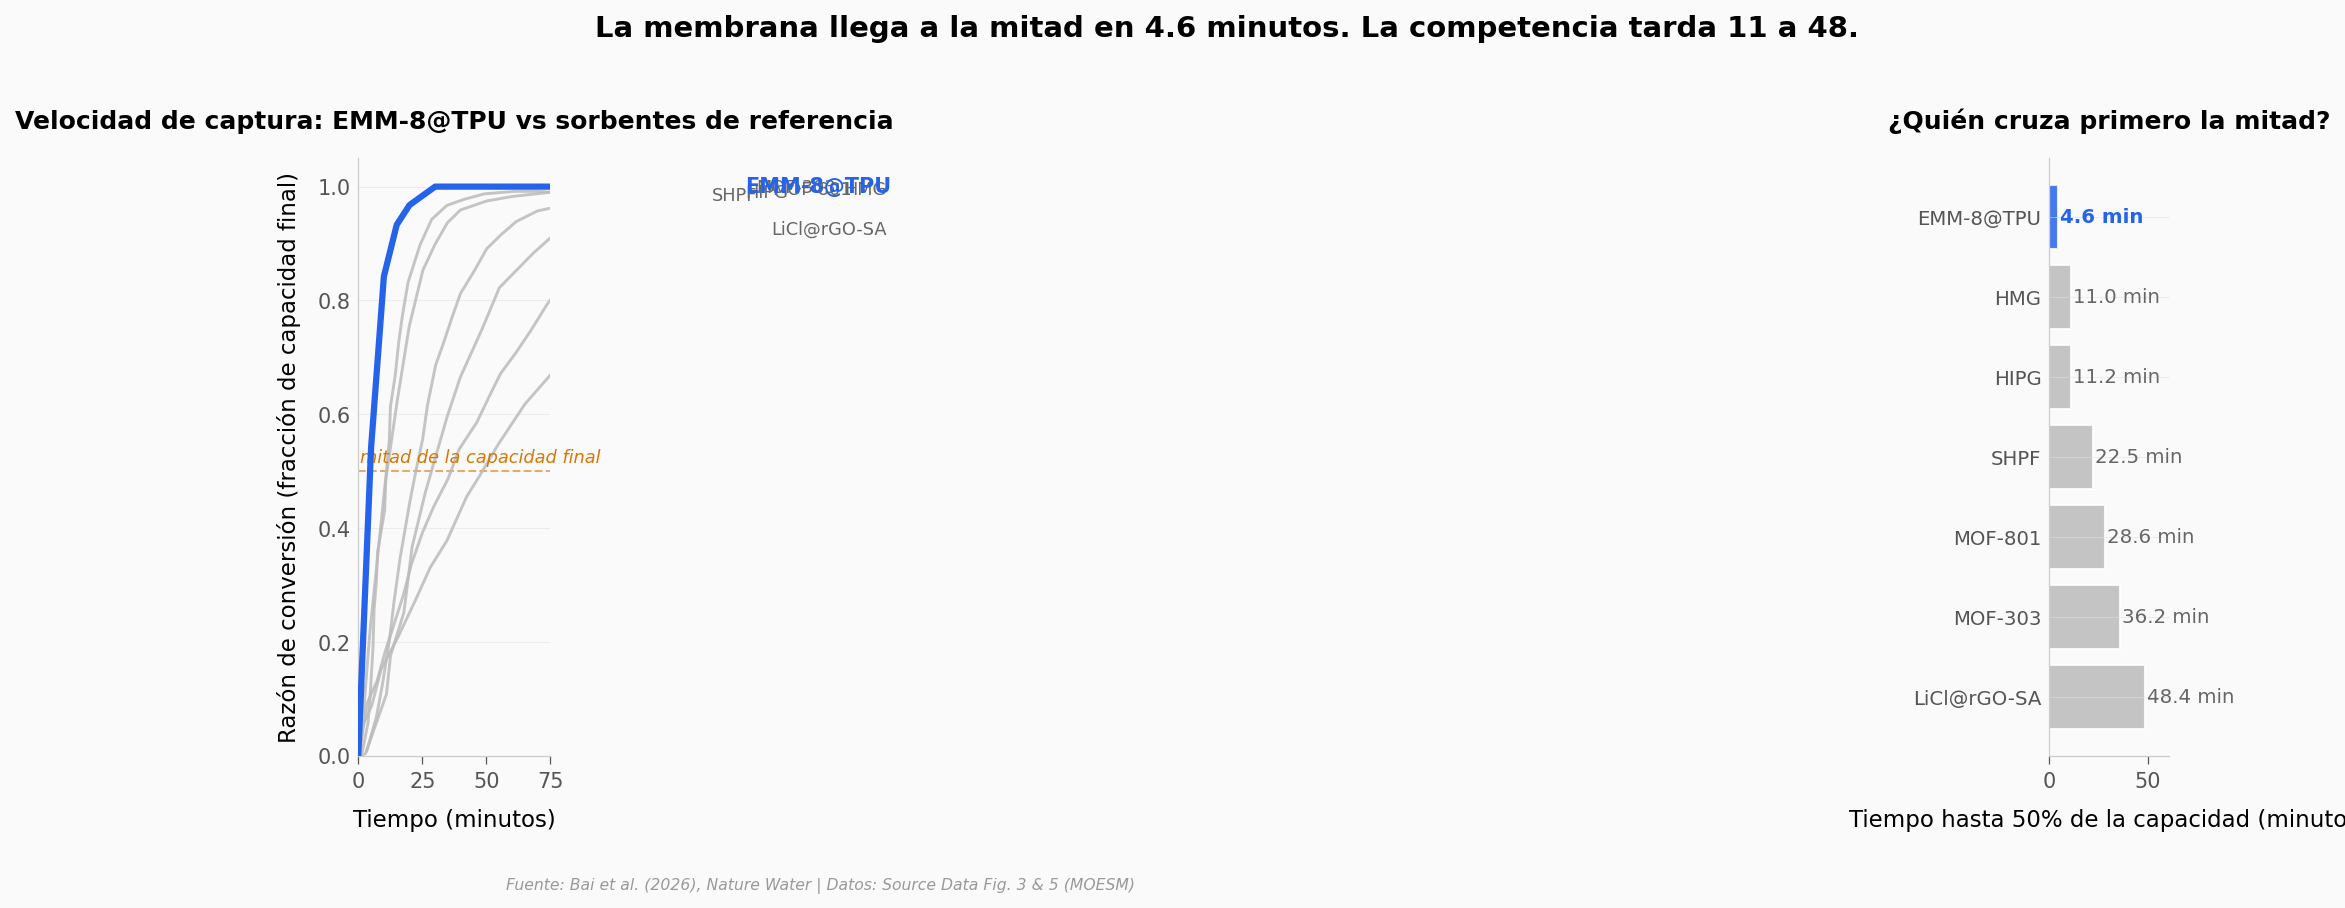


Tiempo a 50% de saturación (interpolado):
  EMM-8@TPU                        4.62 min ⭐ este trabajo
  HMG                             10.99 min
  HIPG                            11.23 min
  SHPF                            22.49 min
  MOF-801                         28.56 min
  MOF-303                         36.15 min
  LiCl@rGO-SA                     48.42 min

La media de la competencia es 5.7× más lenta que EMM-8@TPU.


In [4]:
# Comparativa cinética: tiempo hasta 50% saturación
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios': [1.6, 1]})

# --- Panel izquierdo: curvas conversion vs tiempo ---
ax = axes[0]
sorbentes = comparada['sorbente'].unique()
# EMM-8@TPU destacado, resto en gris con un color por sorbente
cmap = plt.cm.tab10
otros = [s for s in sorbentes if 'EMM-8@TPU' not in s]
for i, s in enumerate(otros):
    sub = comparada[comparada['sorbente'] == s].sort_values('tiempo_min')
    ax.plot(sub['tiempo_min'], sub['conversion_ratio'],
            color=COLOR_CONTEXTO, linewidth=1.4, alpha=0.85, zorder=3)
    # Etiqueta inline al final de la curva
    x_last = sub['tiempo_min'].iloc[-1]
    y_last = sub['conversion_ratio'].iloc[-1]
    ax.text(x_last + 1, y_last, s, fontsize=8.5, color='#666666',
            va='center')

emm = comparada[comparada['sorbente'].str.contains('EMM-8@TPU')].sort_values('tiempo_min')
ax.plot(emm['tiempo_min'], emm['conversion_ratio'],
        color=COLOR_PRINCIPAL, linewidth=3, zorder=6)
ax.text(emm['tiempo_min'].iloc[-1] + 1, emm['conversion_ratio'].iloc[-1],
        'EMM-8@TPU', fontsize=10, fontweight='bold', color=COLOR_PRINCIPAL, va='center')

ax.axhline(y=0.5, color=COLOR_REFERENCIA, linewidth=1, linestyle='--', alpha=0.6)
ax.text(0.5, 0.515, 'mitad de la capacidad final',
        fontsize=8.5, color=COLOR_REFERENCIA, style='italic')

ax.set_xlabel('Tiempo (minutos)', fontsize=11)
ax.set_ylabel('Razón de conversión (fracción de capacidad final)', fontsize=11)
ax.set_xlim(0, 75)
ax.set_ylim(0, 1.05)
ax.set_title('Velocidad de captura: EMM-8@TPU vs sorbentes de referencia',
             fontsize=12, fontweight='bold', pad=14)

# --- Panel derecho: tiempo a 50% ---
ax2 = axes[1]
# Interpolar tiempo al 50% para cada sorbente
def t_50(df):
    df = df.sort_values('tiempo_min')
    t = df['tiempo_min'].values
    c = df['conversion_ratio'].values
    if c.max() < 0.5:
        return np.nan
    idx = np.searchsorted(c, 0.5)
    if idx == 0:
        return t[0]
    # interpolación lineal
    t1, t2 = t[idx-1], t[idx]
    c1, c2 = c[idx-1], c[idx]
    return t1 + (0.5 - c1) * (t2 - t1) / (c2 - c1)

resultados = []
for s in sorbentes:
    sub = comparada[comparada['sorbente'] == s]
    resultados.append((s.split(' (')[0], t_50(sub)))
resultados.sort(key=lambda x: x[1])

nombres = [r[0] for r in resultados]
tiempos = [r[1] for r in resultados]
colores = [COLOR_PRINCIPAL if 'EMM-8@TPU' in n else COLOR_CONTEXTO for n in nombres]

y_pos = np.arange(len(nombres))
ax2.barh(y_pos, tiempos, color=colores, alpha=0.85, edgecolor='white', linewidth=1)
for i, (n, t) in enumerate(resultados):
    ax2.text(t + 1, i, f'{t:.1f} min',
             va='center', fontsize=9.5,
             color=COLOR_PRINCIPAL if 'EMM-8@TPU' in n else '#666666',
             fontweight='bold' if 'EMM-8@TPU' in n else 'normal')

ax2.set_yticks(y_pos)
ax2.set_yticklabels(nombres, fontsize=9.5)
ax2.invert_yaxis()
ax2.set_xlabel('Tiempo hasta 50% de la capacidad (minutos)', fontsize=11)
ax2.set_title('¿Quién cruza primero la mitad?',
              fontsize=12, fontweight='bold', pad=14)
ax2.set_xlim(0, max(tiempos) * 1.25)

fig.suptitle('La membrana llega a la mitad en 4.6 minutos. La competencia tarda 11 a 48.',
             fontsize=14, fontweight='bold', y=1.02)

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/03_cinetica_comparada.png', dpi=200, bbox_inches='tight')
plt.show()

# Print resumen numérico
print(f"\nTiempo a 50% de saturación (interpolado):")
for n, t in resultados:
    flag = ' ⭐ este trabajo' if 'EMM-8@TPU' in n else ''
    print(f"  {n:30s} {t:6.2f} min{flag}")
ratio = np.mean([t for n, t in resultados if 'EMM-8@TPU' not in n]) / [t for n, t in resultados if 'EMM-8@TPU' in n][0]
print(f"\nLa media de la competencia es {ratio:.1f}× más lenta que EMM-8@TPU.")


## La otra mitad del ciclo: liberar el agua

Cargar la membrana es solo la primera parte. Para hacer un dispositivo útil hay que **desorber** —calentar el material para que suelte el agua condensada— y volver a empezar. Si la desorción es lenta, no caben más ciclos en un día.

El paper mide la cinética de desorción a tres temperaturas: 65°C, 70°C y 80°C. Veamos cuánta agua queda atrapada después de 5, 10 y 20 minutos.


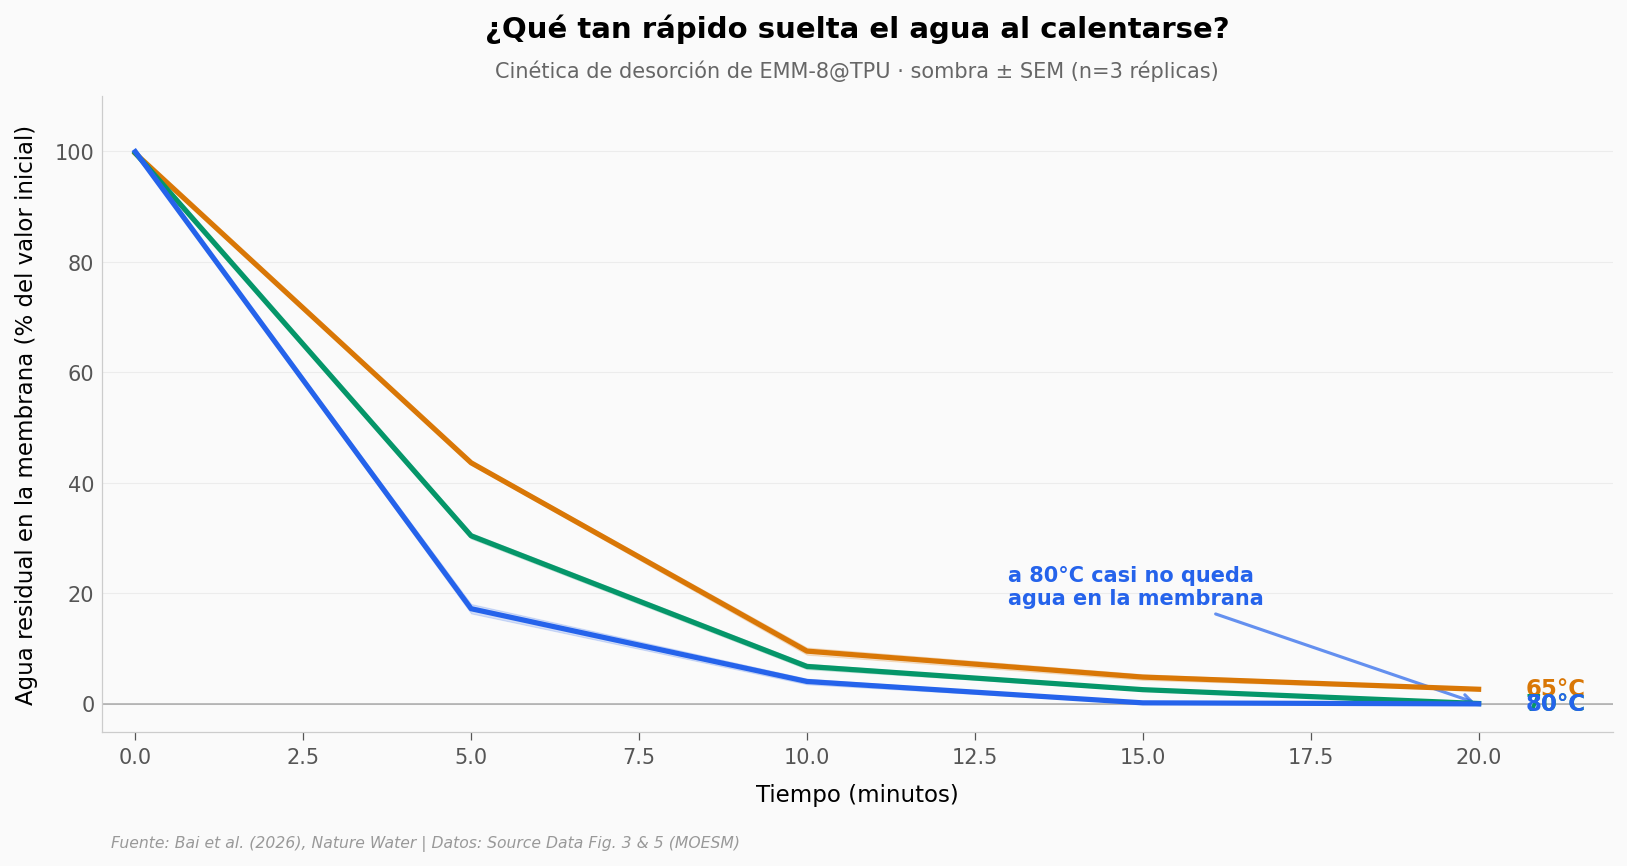

In [5]:
# Cinética de desorción a 3 temperaturas — 3 réplicas cada una
fig, ax = plt.subplots(figsize=(13, 5.5))

color_T = {65: COLOR_REFERENCIA, 70: COLOR_SECUNDARIO, 80: COLOR_PRINCIPAL}

for T, color in color_T.items():
    sub = desorcion[desorcion['T_C'] == T]
    g = sub.groupby('tiempo_min')['water_content_pct'].agg(['mean', 'std', 'count']).reset_index()
    g['sem'] = g['std'] / np.sqrt(g['count'])
    ax.plot(g['tiempo_min'], g['mean'], color=color, linewidth=2.5, zorder=5)
    ax.fill_between(g['tiempo_min'],
                    g['mean'] - g['sem'],
                    g['mean'] + g['sem'],
                    color=color, alpha=0.18)
    # Etiqueta inline al final
    ax.text(g['tiempo_min'].iloc[-1] + 0.7, g['mean'].iloc[-1],
            f'{T}°C', fontsize=11, fontweight='bold', color=color, va='center')

# Línea de referencia: cero residual
ax.axhline(y=0, color='#444444', linewidth=0.8, linestyle='-', alpha=0.4)

# Anotación: a 80°C el residual es prácticamente cero a los 20 min
ax.annotate('a 80°C casi no queda\nagua en la membrana',
            xy=(20, 0), xytext=(13, 18),
            fontsize=10, color=COLOR_PRINCIPAL, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=1.5, alpha=0.7))

ax.set_xlabel('Tiempo (minutos)', fontsize=11)
ax.set_ylabel('Agua residual en la membrana (% del valor inicial)', fontsize=11)
ax.set_title('¿Qué tan rápido suelta el agua al calentarse?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cinética de desorción de EMM-8@TPU · sombra ± SEM (n=3 réplicas)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(-0.5, 22)
ax.set_ylim(-5, 110)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_desorcion.png', dpi=200, bbox_inches='tight')
plt.show()


## El día completo: 72 ciclos sin caer

Sorción rápida + desorción rápida = más ciclos en el mismo tiempo. ¿Cuántos caben en 24 horas? ¿Cuánta agua se acumula?


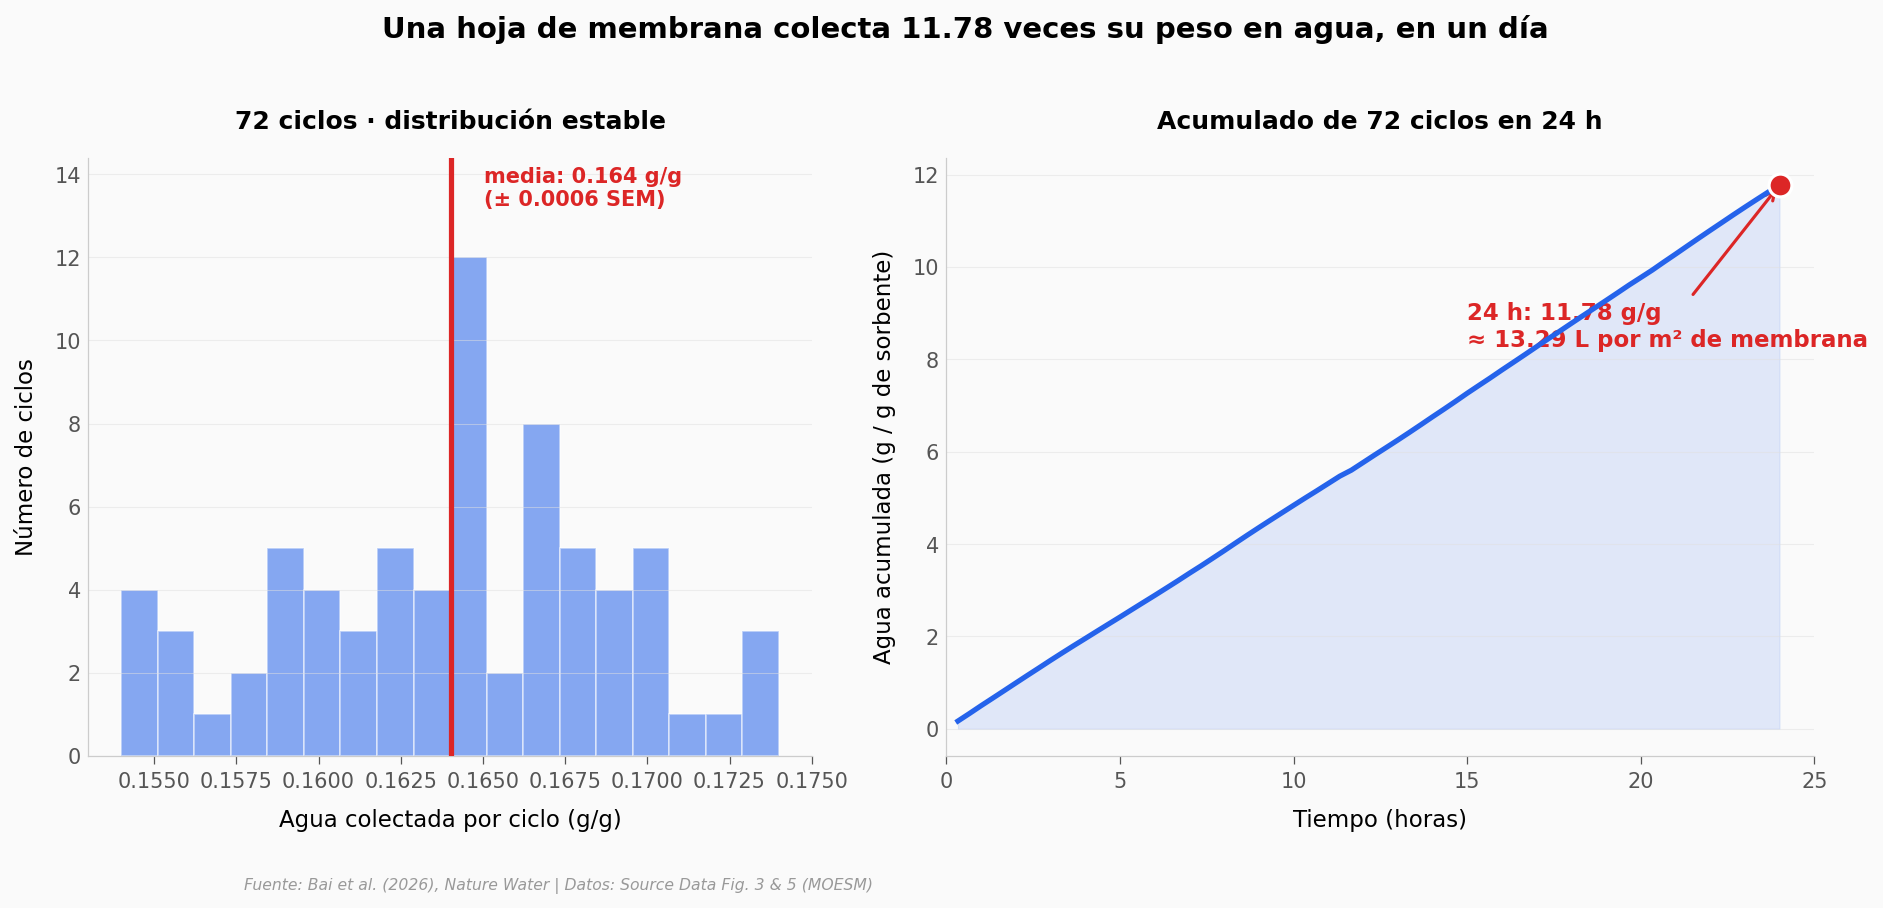


Ciclos totales: 72
Media por ciclo: 0.1640 g/g (SEM = 0.0006, n = 72)
Coeficiente de variación: 3.01%  (estabilidad alta)
Acumulado final: 11.78 g/g  ≈  13.29 L/m²


In [6]:
# Ciclado 24 h: agua por ciclo + acumulado
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios': [1, 1.2]})

# --- Panel izquierdo: distribución de agua por ciclo ---
ax = axes[0]
n, bins, patches = ax.hist(ciclado['colectado_g_g'], bins=18,
                            color=COLOR_PRINCIPAL, alpha=0.55,
                            edgecolor='white', linewidth=0.8)
media = ciclado['colectado_g_g'].mean()
sem_ciclos = ciclado['colectado_g_g'].std(ddof=1) / np.sqrt(len(ciclado))

y_max = n.max() * 1.2
ax.set_ylim(0, y_max)
ax.axvline(x=media, color=COLOR_ALERTA, linewidth=2.5, zorder=10)
ax.text(media + 0.001, y_max * 0.92,
        f'media: {media:.3f} g/g\n(± {sem_ciclos:.4f} SEM)',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold')

ax.set_xlabel('Agua colectada por ciclo (g/g)', fontsize=11)
ax.set_ylabel('Número de ciclos', fontsize=11)
ax.set_title(f'{len(ciclado)} ciclos · distribución estable',
             fontsize=12, fontweight='bold', pad=14)

# --- Panel derecho: agua acumulada en 24 h ---
ax2 = axes[1]
ax2.plot(ciclado['tiempo_h'], ciclado['acumulado_g_g'],
         color=COLOR_PRINCIPAL, linewidth=2.5, zorder=6)
ax2.fill_between(ciclado['tiempo_h'], 0, ciclado['acumulado_g_g'],
                 color=COLOR_PRINCIPAL, alpha=0.12)

# Anotación final
final_t = ciclado['tiempo_h'].iloc[-1]
final_g = ciclado['acumulado_g_g'].iloc[-1]
final_L = ciclado['acumulado_L_m2'].iloc[-1]
ax2.scatter([final_t], [final_g], color=COLOR_ALERTA, s=120,
            zorder=8, edgecolors='white', linewidths=1.5)
ax2.annotate(f'24 h: {final_g:.2f} g/g\n≈ {final_L:.2f} L por m² de membrana',
             xy=(final_t, final_g), xytext=(final_t - 9, final_g - 3.5),
             fontsize=11, color=COLOR_ALERTA, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax2.set_xlabel('Tiempo (horas)', fontsize=11)
ax2.set_ylabel('Agua acumulada (g / g de sorbente)', fontsize=11)
ax2.set_title('Acumulado de 72 ciclos en 24 h',
              fontsize=12, fontweight='bold', pad=14)
ax2.set_xlim(0, 25)

fig.suptitle('Una hoja de membrana colecta 11.78 veces su peso en agua, en un día',
             fontsize=14, fontweight='bold', y=1.02)

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/05_ciclado_24h.png', dpi=200, bbox_inches='tight')
plt.show()

# Resumen numérico
print(f"\nCiclos totales: {ciclado['ciclo'].max()}")
print(f"Media por ciclo: {media:.4f} g/g (SEM = {sem_ciclos:.4f}, n = {len(ciclado)})")
print(f"Coeficiente de variación: {ciclado['colectado_g_g'].std()/media*100:.2f}%  (estabilidad alta)")
print(f"Acumulado final: {final_g:.2f} g/g  ≈  {final_L:.2f} L/m²")


## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| EMM-8@TPU llega al 50% de capacidad en ≈ 4.6 min a 30% RH | ✅ | Interpolación lineal sobre conversion_ratio (ds3). La competencia: 11.0 – 48.4 min (2.4–10.5× más lento) |
| Productividad de 13.79 g/g/día a 59.3% RH | ✅ | Valor directo en productividad_sorbentes.csv (ds4). 54% por encima del mejor sorbente previo (CAL: 8.96 g/g/d a 72.5% RH) |
| Desorción rápida a 80°C — residual cercano a cero en 20 min | ✅ | 3 réplicas convergen a 0% a los 20 min (ds2). A 65°C aún queda 2.65% en 20 min |
| 72 ciclos en 24 h con media estable de 0.164 g/g por ciclo | ✅ | ds5: CV ≈ 3%, sin tendencia descendente visible |
| El paper proyecta escalabilidad industrial ("promising routes") | ⚠️ | Esto es proyección de los autores, no resultado medido. Lo verificado son las propiedades del material a escala de laboratorio (membrana de unos cm²) |

**Limitaciones:**
- Los datos cubren el rango 30–70% de humedad relativa y 25°C; el comportamiento a temperaturas más altas (o más bajas) no está aquí.
- El ciclado se midió durante 24 h continuas. Lo que pase a los 30 días, 6 meses o 2 años (degradación de la matriz TPU, fouling) requiere otro estudio.
- La comparación con sorbentes de literatura usa publicaciones independientes — el equipo no remidió todos los competidores en su propio aparato.

## Ahora tú

¿Qué pasa si cambias las condiciones?

1. **¿A qué humedad relativa la productividad de EMM-8@TPU empata con el mejor competidor (CAL @ 72.5%)?** Pista: interpola sobre `productividad[productividad['sorbente'].str.contains('EMM-8@TPU')]`.
2. **¿Cuál sería el tiempo medio entre ciclos en el experimento de 24 h?** Pista: con 72 ciclos en 24 h, calcula minutos por ciclo y compara con la suma de los tiempos típicos de sorción (5 min) y desorción (20 min a 65°C).
3. **¿Cuánta agua acumularía una hoja de 1 m² en un mes si mantuviera este ritmo?** Pista: usa `acumulado_L_m2` final × 30 — y discute qué supuestos esconde ese cálculo lineal.


In [7]:
# --- EXPERIMENTA AQUÍ ---
# Cuánta agua acumularía un dispositivo de 1 m² en 1 día, 1 semana y 30 días
# (suponiendo que el ritmo de 24 h se mantiene — supuesto fuerte, ver limitaciones)

L_por_m2_dia = ciclado['acumulado_L_m2'].iloc[-1]
escalas = [
    ('1 día',      1),
    ('1 semana',   7),
    ('30 días',   30),
]
print(f"Asumiendo {L_por_m2_dia:.2f} L/m² constantes por día (lineal):\n")
for label, n_dias in escalas:
    L_tot = L_por_m2_dia * n_dias
    print(f"  {label:10s} ·   {L_tot:7.2f} L/m²   (≈ {L_tot * 1000 / 250:.0f} vasos de 250 mL)")

# ¿Y para una persona? OMS sugiere 2 L/día mínimo de agua potable.
# ¿Cuántos m² de membrana harían falta para una persona/día?
m2_persona = 2.0 / L_por_m2_dia
print(f"\nPara cubrir 2 L/día de una persona harían falta ≈ {m2_persona:.2f} m² de membrana.")
print("(asumiendo siempre 38% RH o mejor — en desierto real esta cifra cambia hora a hora)")


Asumiendo 13.29 L/m² constantes por día (lineal):

  1 día      ·     13.29 L/m²   (≈ 53 vasos de 250 mL)
  1 semana   ·     93.00 L/m²   (≈ 372 vasos de 250 mL)
  30 días    ·    398.59 L/m²   (≈ 1594 vasos de 250 mL)

Para cubrir 2 L/día de una persona harían falta ≈ 0.15 m² de membrana.
(asumiendo siempre 38% RH o mejor — en desierto real esta cifra cambia hora a hora)


## Créditos

**Paper original:**
Bai, et al. (2026). *Scalable and flexible zeolite nanosheet membranes for ultrafast water harvesting from air*. **Nature Water**. DOI: [10.1038/s44221-026-00649-2](https://doi.org/10.1038/s44221-026-00649-2)

**Datos:** Source Data (Fig. 3 y Fig. 5) publicados como Supplementary Information de Nature Water. Licencia: CC BY 4.0 del paper.

**Notebook reproducible:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · CC BY-SA 4.0.

## Fuentes

**Paper**: [Scalable and flexible zeolite nanosheet membranes for ultrafast water harvesting from air](https://doi.org/10.1038/s44221-026-00649-2)  
*Nature Water, 2026-05-14*

**Supplementary Material**: [Supplementary Information (PDF)](https://static-content.springer.com/esm/art%3A10.1038%2Fs44221-026-00649-2/MediaObjects/44221_2026_649_MOESM1_ESM.pdf)

**Source Data**:  
- [Fig. 3 — cinéticas de sorción/desorción](https://static-content.springer.com/esm/art%3A10.1038%2Fs44221-026-00649-2/MediaObjects/44221_2026_649_MOESM6_ESM.xlsx)  
- [Fig. 5 — productividad y ciclado](https://static-content.springer.com/esm/art%3A10.1038%2Fs44221-026-00649-2/MediaObjects/44221_2026_649_MOESM8_ESM.xlsx)

*13 afirmaciones verificadas contra estas fuentes*
